# OpenCV 101

## Day 1

### Changing color space

Import library

In [2]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [3]:
os.chdir('../src')
os.getcwd()

'c:\\Users\\user\\Documents\\Projects\\6. Computer Vision\\Code\\computer-vision-playground\\src'

In [4]:
import opencv_utils

%load_ext autoreload
%autoreload 2

In [5]:
os.chdir('..')
os.getcwd()

'c:\\Users\\user\\Documents\\Projects\\6. Computer Vision\\Code\\computer-vision-playground'

There are more than 150 color-space conversion methods available in OpenCV. But we will look into only two, which are most widely used ones: BGR 
 Gray and BGR 
 HSV.

For color conversion, we use the function cv.cvtColor(input_image, flag) where flag determines the type of conversion.

For BGR 
 Gray conversion, we use the flag cv.COLOR_BGR2GRAY. Similarly for BGR 
 HSV, we use the flag cv.COLOR_BGR2HSV. To get other flags, just run following commands in your Python terminal:

In [2]:
flags = [i for i in dir(cv) if i.startswith('COLOR_')]
print( flags )

['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB', 'COLOR_BAYER_BGGR2RGBA', 'COLOR_BAYER_BGGR2RGB_EA', 'COLOR_BAYER_BGGR2RGB_VNG', 'COLOR_BAYER_GB2BGR', 'COLOR_BAYER_GB2BGRA', 'COLOR_BAYER_GB2BGR_EA', 'COLOR_BAYER_GB2BGR_VNG', 'COLOR_BAYER_GB2GRAY', 'COLOR_BAYER_GB2RGB', 'COLOR_BAYER_GB2RGBA', 'COLOR_BAYER_GB2RGB_EA', 'COLOR_BAYER_GB2RGB_VNG', 'COLOR_BAYER_GBRG2BGR', 'COLOR_BAYER_GBRG2BGRA', 'COLOR_BAYER_GBRG2BGR_EA', 'COLOR_BAYER_GBRG2BGR_VNG', 'COLOR_BAYER_GBRG2GRAY', 'COLOR_BAYER_GBRG2RGB', 'COLOR_BAYER_GBRG2RGBA', 'COLOR_BAYER_GBRG2RGB_EA', 'COLOR_BAYER_GBRG2RGB_VNG', 'COLOR_BAYER_GR2BGR', 'COLOR_BAYER_GR2BGRA', 'COLOR_BAYER_GR2BGR_EA', 'COLOR_BAYER_GR2BGR_VNG', 'COLOR_

Color conversion examples-

In [ ]:
# Load image
img = opencv_utils.read_image(file_path = "./data/raw/bird.jpg")

# Convert image BGR -> GreyScale
flag = cv.COLOR_BGR2GRAY
gray = cv.cvtColor(img, flag)

# Show grayscale image
cv.imshow("Grayscale Image", gray)
cv.waitKey(0)
cv.destroyAllWindows()

In [35]:
# Load image
img = opencv_utils.read_image(file_path = "./data/raw/bird.jpg")

# Convert image BGR -> HSV
flag = cv.COLOR_BGR2HSV
hsv = cv.cvtColor(img, flag)

In [36]:
# Split channels
h, s, v = cv.split(hsv)

# Show each channel
cv.imshow("Hue", h)
cv.imshow("Saturation", s)
cv.imshow("Value", v)

# # Optional: Apply colormap for prettier visualization
# hue_colored = cv.applyColorMap(h, cv.COLORMAP_JET)
# cv.imshow("Hue (colormapped)", hue_colored)
# saturation_colored = cv.applyColorMap(s, cv.COLORMAP_JET)
# cv.imshow("Saturation (colormapped)", saturation_colored)
# value_colored = cv.applyColorMap(v, cv.COLORMAP_JET)
# cv.imshow("Value (colormapped)", value_colored)

# Wait for key press and close
cv.waitKey(0)
cv.destroyAllWindows()

In [37]:
# cv.imwrite("starry_night.png", img)

### Geometric Transformations of Images

Transformations: <br>
OpenCV provides two transformation functions, cv.warpAffine and cv.warpPerspective, with which you can perform all kinds of transformations. cv.warpAffine takes a 2x3 transformation matrix while cv.warpPerspective takes a 3x3 transformation matrix as input.

Scaling: <br>
Scaling is just resizing of the image. OpenCV comes with a function cv.resize() for this purpose. The size of the image can be specified manually, or you can specify the scaling factor. Different interpolation methods are used. Preferable interpolation methods are cv.INTER_AREA for shrinking and cv.INTER_CUBIC (slow) & cv.INTER_LINEAR for zooming. By default, the interpolation method cv.INTER_LINEAR is used for all resizing purposes. You can resize an input image with either of following methods:

In [ ]:
# Load image
img = opencv_utils.read_image(file_path = "./data/raw/bird.jpg")


res = cv.resize(img,None,fx=2, fy=2, interpolation = cv.INTER_CUBIC)

# #OR resize by providing size

# height, width = img.shape[:2]
# res = cv.resize(img,(2*width, 2*height), interpolation = cv.INTER_CUBIC)

# Show grayscale image
cv.imshow("Scaled Image", res)
cv.waitKey(0)
cv.destroyAllWindows()

Translation: <br>
Translation is the shifting of an object's location. If you know the shift in the (x,y) direction and let it be, you can create the transformation matrix as follows: <br> <br>
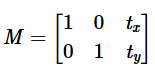 <br><br>
You can take make it into a Numpy array of type np.float32 and pass it into the cv.warpAffine() function. See the below example for a shift of (100,50):

In [ ]:
# Load image
img = opencv_utils.read_image("./data/raw/bird.jpg", cv.IMREAD_GRAYSCALE)

rows,cols = img.shape

M = np.float32([[1,0,100],[0,1,50]])
dst = cv.warpAffine(img,M,(cols,rows))

cv.imshow("Translated Image", dst)
cv.waitKey(0)
cv.destroyAllWindows()

Rotation
Rotation of an image for an angle is achieved by the transformation matrix of the form- <br><br>
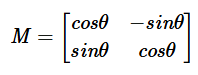 <br><br>
But OpenCV provides scaled rotation with adjustable center of rotation so that you can rotate at any location you prefer. The modified transformation matrix is given by <br><br>
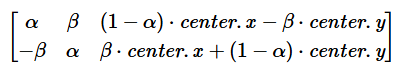<br>
where:<br><br>
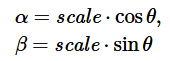 <br><br>
To find this transformation matrix, OpenCV provides a function, cv.getRotationMatrix2D. Check out the below example which rotates the image by 90 degree with respect to center without any scaling.

In [50]:
# Load image
img = opencv_utils.read_image("./data/raw/bird.jpg", cv.IMREAD_GRAYSCALE)

rows,cols = img.shape

# cols-1 and rows-1 are the coordinate limits.
M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),90,0.5)
dst = cv.warpAffine(img,M,(cols,rows))

cv.imshow("Translated Image", dst)
cv.waitKey(0)
cv.destroyAllWindows()

Affine Transformation: <br>
In affine transformation, all parallel lines in the original image will still be parallel in the output image. To find the transformation matrix, we need three points from the input image and their corresponding locations in the output image. Then cv.getAffineTransform will create a 2x3 matrix which is to be passed to cv.warpAffine.

Check the below example, and also look at the points I selected (which are marked in green color):

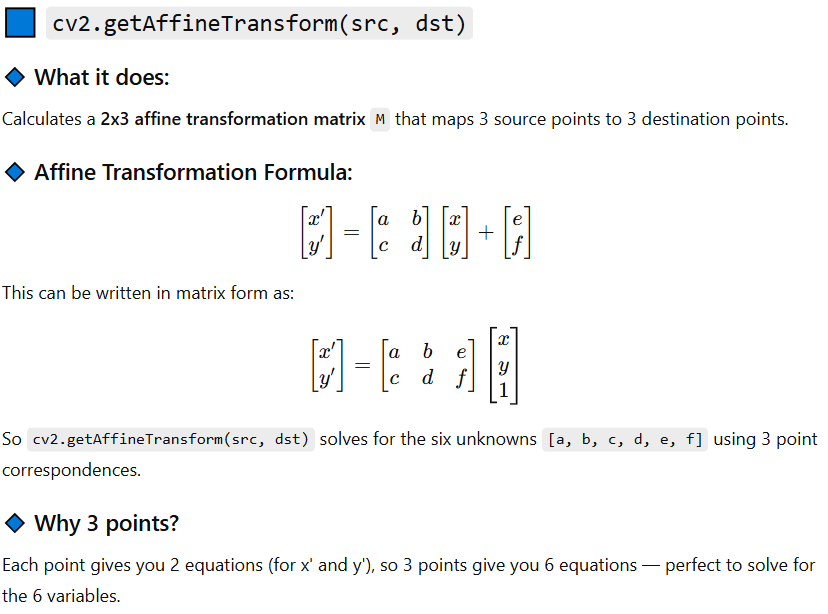

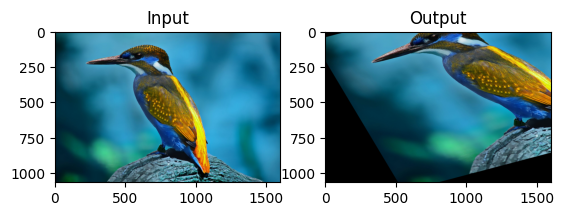

In [ ]:
# Load image
img = opencv_utils.read_image("./data/raw/bird.jpg")

rows,cols,ch = img.shape

pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])

M = cv.getAffineTransform(pts1,pts2)

dst = cv.warpAffine(img,M,(cols,rows))

plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()

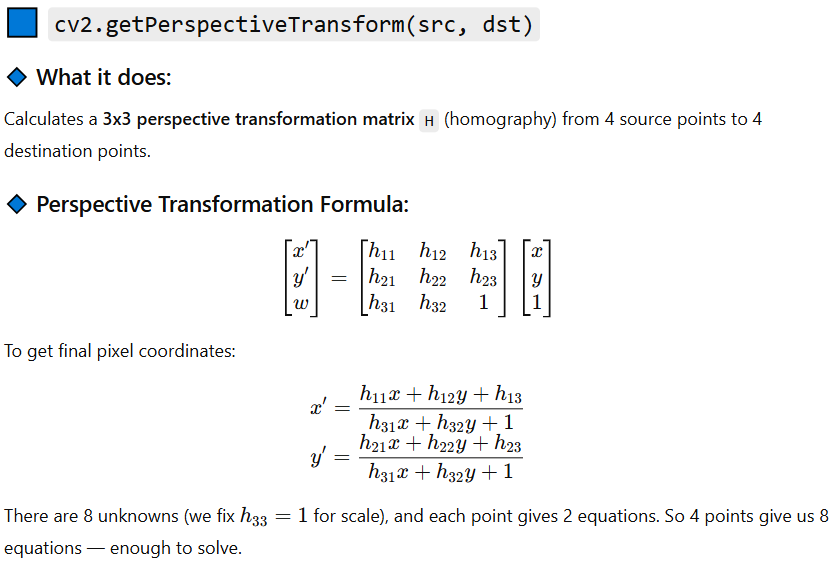

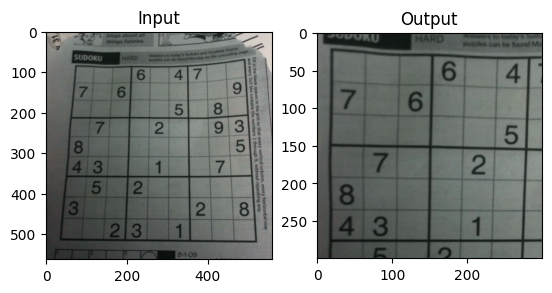

In [ ]:
img = opencv_utils.read_image("./data/raw/sudoku.png")
assert img is not None, "file could not be read, check with os.path.exists()"
rows,cols,ch = img.shape

pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])

M =  (pts1,pts2)

dst = cv.warpPerspective(img,M,(300,300))

plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()

### Smoothing Images

Goals<br><br>
Learn to:<br>
- Blur images with various low pass filters
- Apply custom-made filters to images (2D convolution) <br><br>
2D Convolution ( Image Filtering )<br>
As in one-dimensional signals, images also can be filtered with various low-pass filters (LPF), high-pass filters (HPF), etc. LPF helps in removing noise, blurring images, etc. HPF filters help in finding edges in images.<br>
OpenCV provides a function cv.filter2D() to convolve a kernel with an image. As an example, we will try an averaging filter on an image. A 5x5 averaging filter kernel will look like the below:<br><br>
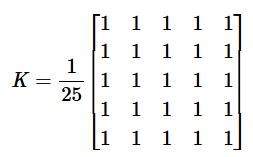<br><br>
The operation works like this: keep this kernel above a pixel, add all the 25 pixels below this kernel, take the average, and replace the central pixel with the new average value. This operation is continued for all the pixels in the image.

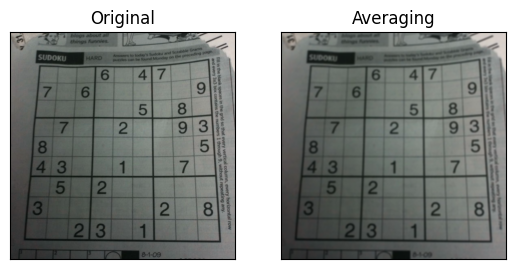

In [69]:
# Load image
img = opencv_utils.read_image("./data/raw/sudoku.png")

kernel = np.ones((5,5),np.float32)/25
dst = cv.filter2D(img,-1,kernel)

plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

#### Image Blurring (Image Smoothing)

Image blurring is achieved by convolving the image with a low-pass filter kernel. It is useful for removing noise. It actually removes high frequency content (eg: noise, edges) from the image. So edges are blurred a little bit in this operation (there are also blurring techniques which don't blur the edges). OpenCV provides four main types of blurring techniques.

##### Averaging

This is done by convolving an image with a normalized box filter. It simply takes the average of all the pixels under the kernel area and replaces the central element. This is done by the function cv.blur() or cv.boxFilter(). Check the docs for more details about the kernel. We should specify the width and height of the kernel. A 3x3 normalized box filter would look like the below:

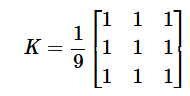

Note-

If you do not want to use a normalized box filter, use cv.boxFilter(). Pass an argument normalize=False to the function.


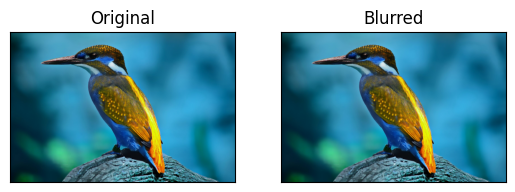

In [96]:
# Load image
img = opencv_utils.read_image("./data/raw/bird.jpg")

# Average blur
# blur = cv.blur(img,(35,35))
# blur = cv.boxFilter(img, -1, (30,30), normalize=True)

# Gaussian Blur
# blur = cv.GaussianBlur(img,(11,11),0)

# Median Blur
# blur = cv.medianBlur(img,51)

# Bilateral Filter
blur = cv.bilateralFilter(img,5,75,75)

plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

#### Bilateral Filter

Blur comes from averaging across edges, Bilateral filter has additional Edge term in the normal Gaussian filter

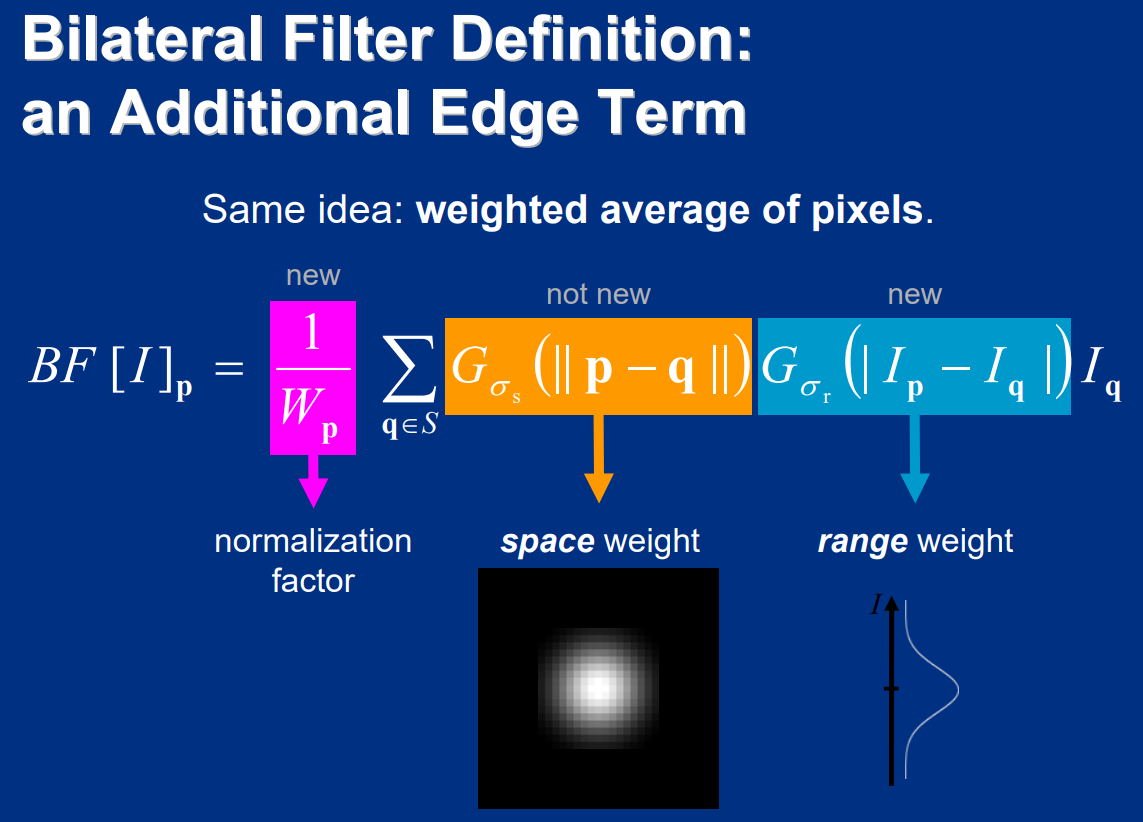

### Histograms

Theory

So what is histogram? You can consider histogram as a graph or plot, which gives you an overall idea about the intensity distribution of an image. It is a plot with pixel values (ranging from 0 to 255, not always) in X-axis and corresponding number of pixels in the image on Y-axis.

It is just another way of understanding the image. By looking at the histogram of an image, you get intuition about contrast, brightness, intensity distribution etc of that image. Almost all image processing tools today, provides features on histogram.

#### Histogram Calculation in OpenCV

So now we use cv.calcHist() function to find the histogram. Let's familiarize with the function and its parameters :

cv.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])

images : it is the source image of type uint8 or float32. it should be given in square brackets, ie, "[img]".<br>
channels : it is also given in square brackets. It is the index of channel for which we calculate histogram. For example, if input is grayscale image, its value is [0]. For color image, you can pass [0], [1] or [2] to calculate histogram of blue, green or red channel respectively.<br>
mask : mask image. To find histogram of full image, it is given as "None". But if you want to find histogram of particular region of image, you have to create a mask image for that and give it as mask. (I will show an example later.)<br>
histSize : this represents our BIN count. Need to be given in square brackets. For full scale, we pass [256].<br>
ranges : this is our RANGE. Normally, it is [0,256].<br>

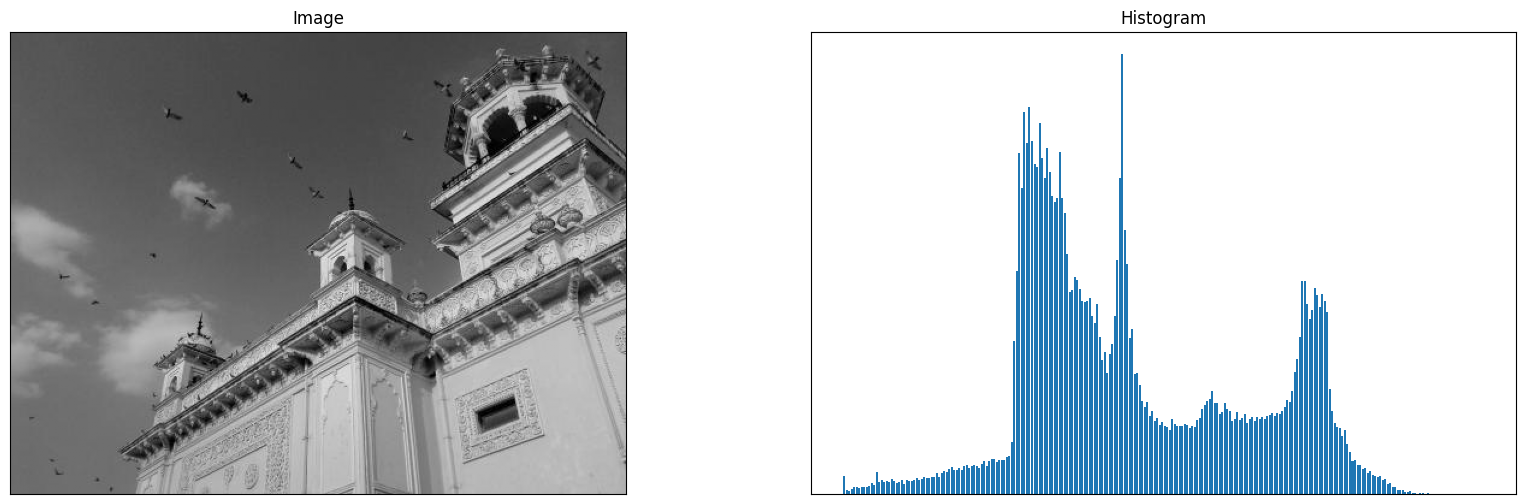

In [152]:
# # Load image
# img = opencv_utils.read_image("./data/raw/bird.jpg", cv.IMREAD_GRAYSCALE)

# Load image
img = opencv_utils.read_image("./data/raw/home.jpg", cv.IMREAD_GRAYSCALE)

hist = cv.calcHist([img],[0],None,[256],[0,256])

plt.figure(figsize=(20,6))
plt.subplot(121),plt.imshow(img, 'gray'),plt.title('Image')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.bar(x=np.arange(0,256), height=hist.flatten()),plt.title('Histogram')
plt.xticks([]), plt.yticks([])
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_1884\3777287911.py:10: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(122),plt.hist(img.ravel(),256,[0,256]),plt.title('Histogram')


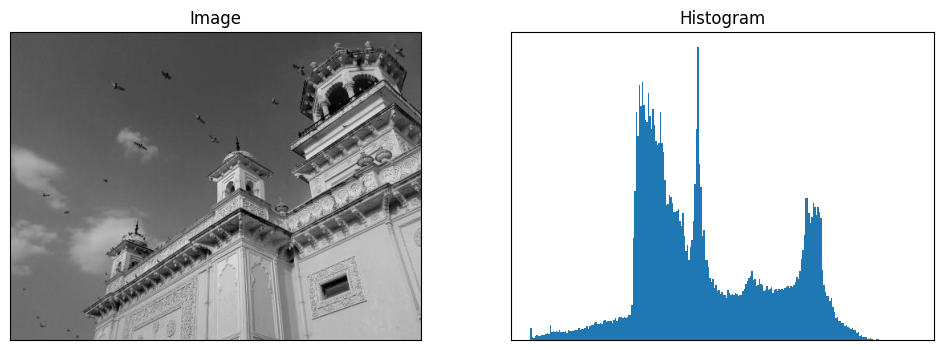

In [148]:
# # Load image
# img = opencv_utils.read_image("./data/raw/bird.jpg", cv.IMREAD_GRAYSCALE)

# Load image
img = opencv_utils.read_image("./data/raw/home.jpg", cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,4))
plt.subplot(121),plt.imshow(img, 'gray'),plt.title('Image')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.hist(img.ravel(),256,[0,256]),plt.title('Histogram')
plt.xticks([]), plt.yticks([])
plt.show()

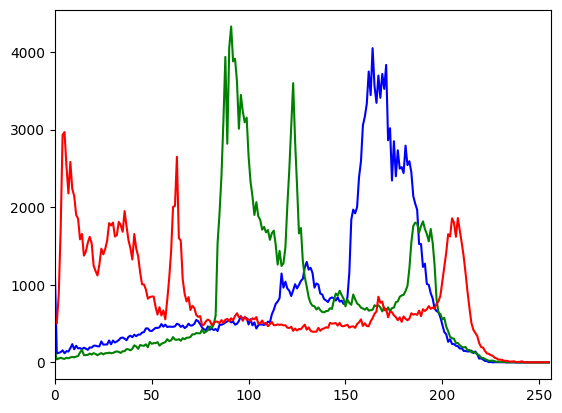

In [143]:
# Load image
img = opencv_utils.read_image("./data/raw/home.jpg")

color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv.calcHist([img],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
plt.show()

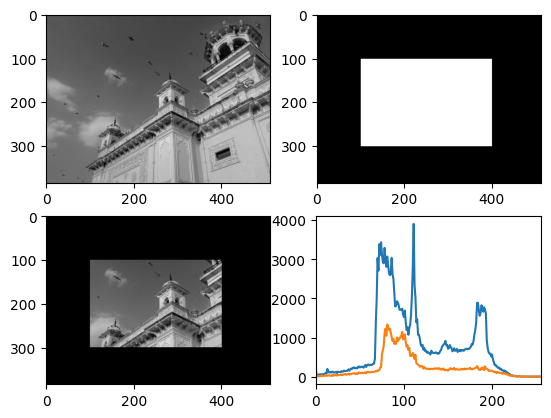

In [142]:
# Load image
img = opencv_utils.read_image("./data/raw/home.jpg", cv.IMREAD_GRAYSCALE)

# create a mask
mask = np.zeros(img.shape[:2], np.uint8)
mask[100:300, 100:400] = 255
masked_img = cv.bitwise_and(img,img,mask = mask)
 
# Calculate histogram with mask and without mask
# Check third argument for mask
hist_full = cv.calcHist([img],[0],None,[256],[0,256])
hist_mask = cv.calcHist([img],[0],mask,[256],[0,256])
 
plt.subplot(221), plt.imshow(img, 'gray')
plt.subplot(222), plt.imshow(mask,'gray')
plt.subplot(223), plt.imshow(masked_img, 'gray')
plt.subplot(224), plt.plot(hist_full), plt.plot(hist_mask)
plt.xlim([0,256])
 
plt.show()

#### Histogram equalization

Theory
Consider an image whose pixel values are confined to some specific range of values only. For eg, brighter image will have all pixels confined to high values. But a good image will have pixels from all regions of the image. So you need to stretch this histogram to either ends (as given in below image, from wikipedia) and that is what Histogram Equalization does (in simple words). This normally improves the contrast of the image.

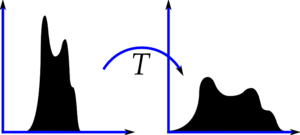

I would recommend you to read the wikipedia page on Histogram Equalization for more details about it. It has a very good explanation with worked out examples, so that you would understand almost everything after reading that. Instead, here we will see its Numpy implementation. After that, we will see OpenCV function.

C:\Users\user\AppData\Local\Temp\ipykernel_12724\442472568.py:10: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.flatten(),256,[0,256], color = 'r')


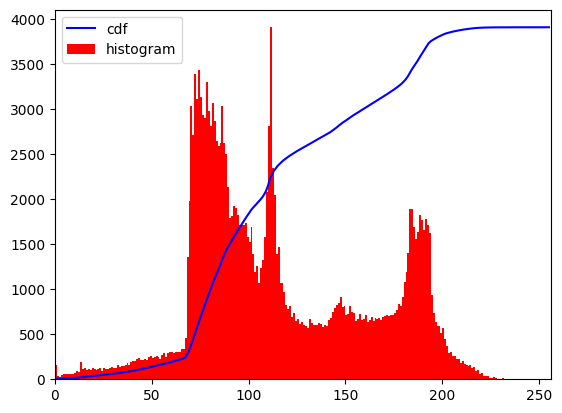

In [17]:
# Load image
img = opencv_utils.read_image("./data/raw/home.jpg", cv.IMREAD_GRAYSCALE)

hist,bins = np.histogram(img.flatten(),256,[0,256])

cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()

plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()

You can see histogram lies in brighter region. We need the full spectrum. For that, we need a transformation function which maps the input pixels in brighter region to output pixels in full region. That is what histogram equalization does.

Now we find the minimum histogram value (excluding 0) and apply the histogram equalization equation as given in wiki page. But I have used here, the masked array concept array from Numpy. For masked array, all operations are performed on non-masked elements. You can read more about it from Numpy docs on masked arrays.

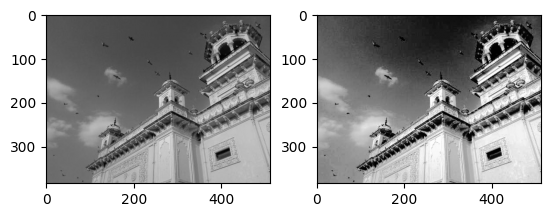

In [18]:
cdf_m = np.ma.masked_equal(cdf,0)
cdf_m = (cdf_m - cdf_m.min())*255/(cdf_m.max()-cdf_m.min())
cdf = np.ma.filled(cdf_m,0).astype('uint8')

img2 = cdf[img]

plt.subplot(221), plt.imshow(img, 'gray')
plt.subplot(222), plt.imshow(img2,'gray')

plt.show()

##### Histogram Equalization in OpenCV

OpenCV has a function to do this, cv.equalizeHist(). Its input is just grayscale image and output is our histogram equalized image.

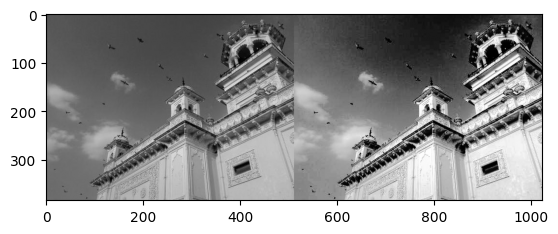

In [20]:
# Load image
img = opencv_utils.read_image("./data/raw/home.jpg", cv.IMREAD_GRAYSCALE)

equ = cv.equalizeHist(img)
res = np.hstack((img,equ)) #stacking images side-by-side

plt.imshow(res,'gray')
plt.show()

##### CLAHE (Contrast Limited Adaptive Histogram Equalization)
The first histogram equalization we just saw, considers the global contrast of the image. In many cases, it is not a good idea. For example, below image shows an input image and its result after global histogram equalization.

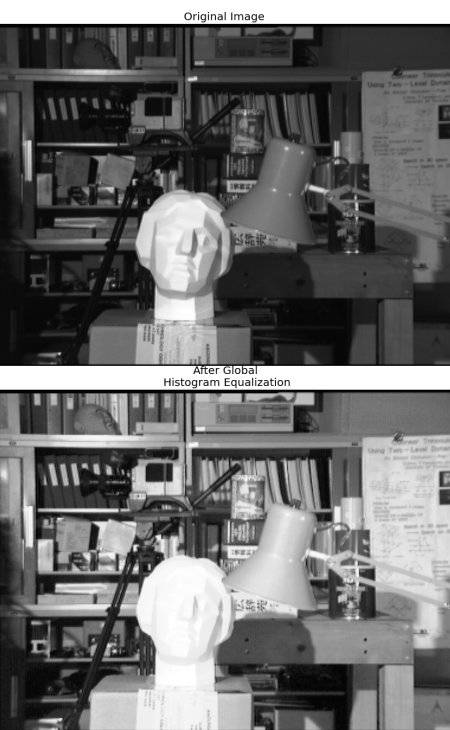

It is true that the background contrast has improved after histogram equalization. But compare the face of statue in both images. We lost most of the information there due to over-brightness. It is because its histogram is not confined to a particular region as we saw in previous cases (Try to plot histogram of input image, you will get more intuition).

So to solve this problem, adaptive histogram equalization is used. In this, image is divided into small blocks called "tiles" (tileSize is 8x8 by default in OpenCV). Then each of these blocks are histogram equalized as usual. So in a small area, histogram would confine to a small region (unless there is noise). If noise is there, it will be amplified. To avoid this, contrast limiting is applied. If any histogram bin is above the specified contrast limit (by default 40 in OpenCV), those pixels are clipped and distributed uniformly to other bins before applying histogram equalization. After equalization, to remove artifacts in tile borders, bilinear interpolation is applied.

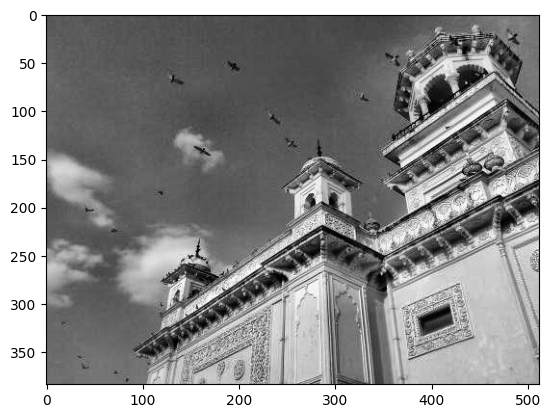

In [50]:
# Load image
img = opencv_utils.read_image("./data/raw/home.jpg", cv.IMREAD_GRAYSCALE)
 
# create a CLAHE object (Arguments are optional).
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(img)

plt.imshow(cl1,'gray')
plt.show()

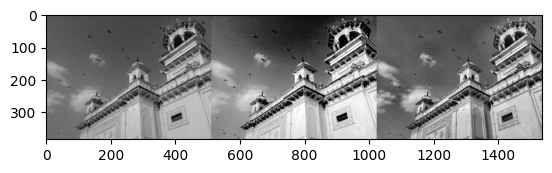

In [51]:
res = np.hstack((img,equ, cl1)) #stacking images side-by-side

plt.imshow(res,'gray')
plt.show()

#### Plotting 2D Histograms

2D Histogram in OpenCV<br>
It is quite simple and calculated using the same function, cv.calcHist(). For color histograms, we need to convert the image from BGR to HSV. (Remember, for 1D histogram, we converted from BGR to Grayscale). For 2D histograms, its parameters will be modified as follows:<br>

- channels = [0,1] because we need to process both H and S plane.<br>
- bins = [180,256] 180 for H plane and 256 for S plane.<br>
- range = [0,180,0,256] Hue value lies between 0 and 180 & Saturation lies between 0 and 256.<br>

Method - 1 : Using cv.imshow()<br>
The result we get is a two dimensional array of size 180x256. So we can show them as we do normally, using cv.imshow() function. It will be a grayscale image and it won't give much idea what colors are there, unless you know the Hue values of different colors.<br>

Method - 2 : Using Matplotlib<br>
We can use matplotlib.pyplot.imshow() function to plot 2D histogram with different color maps. It gives us a much better idea about the different pixel density. But this also, doesn't gives us idea what color is there on a first look, unless you know the Hue values of different colors. Still I prefer this method. It is simple and better.<br>

In [52]:
# Load image
img = opencv_utils.read_image("./data/raw/home.jpg")
hsv = cv.cvtColor(img,cv.COLOR_BGR2HSV)

h = hsv[:,:,0]
s = hsv[:,:,1]

hist, xbins, ybins = np.histogram2d(h.ravel(),s.ravel(),[180,256],[[0,180],[0,256]])

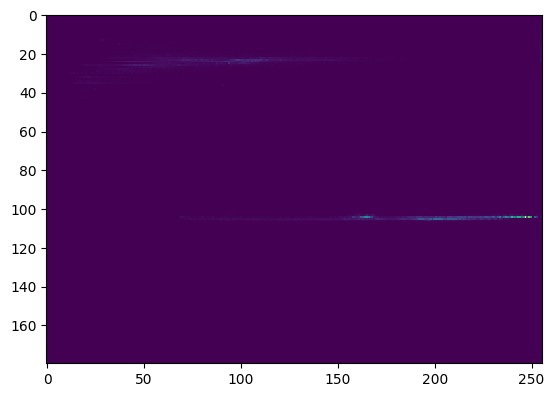

In [53]:
# Load image
img = opencv_utils.read_image("./data/raw/home.jpg")
hsv = cv.cvtColor(img,cv.COLOR_BGR2HSV)

hist = cv.calcHist([hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])

plt.imshow(hist,interpolation = 'nearest')
plt.show()

In histogram, you can see some high values near H = 100 and S = 200. It corresponds to blue of sky. Similarly another peak can be seen near H = 25 and S = 100. It corresponds to yellow of the palace. You can verify it with any image editing tools like GIMP.

##### Method 3 : OpenCV sample style !!
There is a sample code for color-histogram in OpenCV-Python2 samples (samples/python/color_histogram.py). If you run the code, you can see the histogram shows the corresponding color also. Or simply it outputs a color coded histogram. Its result is very good (although you need to add extra bunch of lines).

In that code, the author created a color map in HSV. Then converted it into BGR. The resulting histogram image is multiplied with this color map. He also uses some preprocessing steps to remove small isolated pixels, resulting in a good histogram.

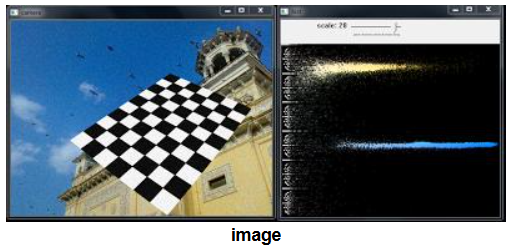

#### Histogram Backprojection

Theory

It was proposed by Michael J. Swain , Dana H. Ballard in their paper Indexing via color histograms.

What is it actually in simple words? It is used for image segmentation or finding objects of interest in an image. In simple words, it creates an image of the same size (but single channel) as that of our input image, where each pixel corresponds to the probability of that pixel belonging to our object. In more simpler words, the output image will have our object of interest in more white compared to remaining part. Well, that is an intuitive explanation. (I can't make it more simpler). Histogram Backprojection is used with camshift algorithm etc.

How do we do it ? We create a histogram of an image containing our object of interest (in our case, the ground, leaving player and other things). The object should fill the image as far as possible for better results. And a color histogram is preferred over grayscale histogram, because color of the object is a better way to define the object than its grayscale intensity. We then "back-project" this histogram over our test image where we need to find the object, ie in other words, we calculate the probability of every pixel belonging to the ground and show it. The resulting output on proper thresholding gives us the ground alone.

##### Algorithm in Numpy

1. First we need to calculate the color histogram of both the object we need to find (let it be 'M') and the image where we are going to search (let it be 'I').

In [ ]:
#roi is the object or region of object we need to find
roi = opencv_utils.read_image("./data/raw/grass.png")
hsv = cv.cvtColor(roi,cv.COLOR_BGR2HSV)
 
#target is the image we search in
target = opencv_utils.read_image("./data/raw/messi.webp")
hsvt = cv.cvtColor(target,cv.COLOR_BGR2HSV)
 
# Find the histograms using calcHist. Can be done with np.histogram2d also
M = cv.calcHist([hsv],[0, 1], None, [180, 256], [0, 180, 0, 256] )
I = cv.calcHist([hsvt],[0, 1], None, [180, 256], [0, 180, 0, 256] )

R = np.where(I!=0, M/I,0)


C:\Users\user\AppData\Local\Temp\ipykernel_12724\2755904925.py:14: RuntimeWarning: divide by zero encountered in divide
  R = np.where(I!=0, M/I,0)
C:\Users\user\AppData\Local\Temp\ipykernel_12724\2755904925.py:14: RuntimeWarning: invalid value encountered in divide
  R = np.where(I!=0, M/I,0)


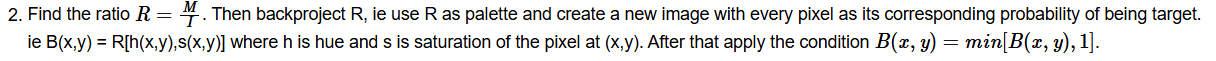

In [62]:
h,s,v = cv.split(hsvt)
B = R[h.ravel(),s.ravel()]
B = np.minimum(B,1)
B = B.reshape(hsvt.shape[:2])

In [63]:
disc = cv.getStructuringElement(cv.MORPH_ELLIPSE,(5,5))
cv.filter2D(B,-1,disc,B)
B = np.uint8(B)
cv.normalize(B,B,0,255,cv.NORM_MINMAX)

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [255, 255, 240, ..., 150, 135, 135],
       [255, 240, 225, ..., 105,  90,  75],
       [255, 240, 210, ...,  75,  60,  45]], shape=(211, 300), dtype=uint8)

Now the location of maximum intensity gives us the location of object. If we are expecting a region in the image, thresholding for a suitable value gives a nice result.

In [65]:
ret,thresh = cv.threshold(B,50,255,0)

##### Backprojection in OpenCV

OpenCV provides an inbuilt function cv.calcBackProject(). Its parameters are almost same as the cv.calcHist() function. One of its parameter is histogram which is histogram of the object and we have to find it. Also, the object histogram should be normalized before passing on to the backproject function. It returns the probability image. Then we convolve the image with a disc kernel and apply threshold.

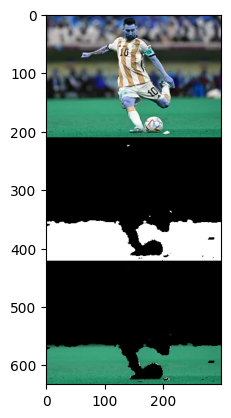

In [71]:
import numpy as np
import cv2 as cv

roi = opencv_utils.read_image("./data/raw/grass.png")
hsv = cv.cvtColor(roi,cv.COLOR_BGR2HSV)

target = opencv_utils.read_image("./data/raw/messi.webp")
hsvt = cv.cvtColor(target,cv.COLOR_BGR2HSV)

# calculating object histogram
roihist = cv.calcHist([hsv],[0, 1], None, [180, 256], [0, 180, 0, 256] )

# normalize histogram and apply backprojection
cv.normalize(roihist,roihist,0,255,cv.NORM_MINMAX)
dst = cv.calcBackProject([hsvt],[0,1],roihist,[0,180,0,256],1)

# Now convolute with circular disc
disc = cv.getStructuringElement(cv.MORPH_ELLIPSE,(5,5))
cv.filter2D(dst,-1,disc,dst)

# threshold and binary AND
ret,thresh = cv.threshold(dst,50,255,0)
thresh = cv.merge((thresh,thresh,thresh))
res = cv.bitwise_and(target,thresh)

res = np.vstack((target,thresh,res))

plt.imshow(res)
plt.show()